
# 05 · Dynamic Sequential Forecasting & Submission

The previous notebooks all trained and evaluated against static, pre-computed
features. **Inference on genuinely future matches can't do that** — there's no
"last 5 matches" column waiting in a CSV for a fixture that hasn't been played
yet. This notebook rebuilds the same 34 features *on the fly*, one match at a
time, in chronological order, updating an in-memory state (form, head-to-head
history, rest days) as it goes — the same shape of loop a production
scheduled job would run before each matchday.

We close with a few sanity-check plots on the generated predictions, since a
silently broken state update is the kind of bug that won't throw an error —
it'll just quietly produce nonsense predictions for every match after the
first one.


In [1]:
import pandas as pd
import numpy as np
import pickle
import json
from tqdm.notebook import tqdm
import lightgbm as lgb
import catboost as cb
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('.')
from plot_style import set_style, PALETTE
set_style()


In [2]:
model_team_lgbm = lgb.Booster(model_file='../models/lgb_team_model_opt.json')
model_opp_lgbm = lgb.Booster(model_file='../models/lgb_opp_model_opt.json')
model_team_cat = cb.CatBoostRegressor().load_model('../models/model_cb_tim_opt.json', format='json')
model_opp_cat = cb.CatBoostRegressor().load_model('../models/model_cb_opp_opt.json', format='json')

with open('../data/features_v6_1.json', 'r') as f:
    features_v6_1 = json.load(f)

test_df = pd.read_csv('../data/test.csv')
test_df['date'] = pd.to_datetime(test_df['date'])
test_df = test_df.sort_values('date').reset_index(drop=True)
print(f"{len(test_df)} fixtures to forecast, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")


400 fixtures to forecast, 2023-07-01 -> 2024-06-26


## Seeding the state from training history

In production this `state` would be a warm-started snapshot carried over from
the end of the training period (saved as `state_2011.pkl` in the original
pipeline). Here we rebuild that starting state directly from the cleaned
training set, so Elo and form aren't reset to a cold "1500 / no history"
default for teams we've actually seen plenty of matches from.

In [3]:
train_hist = pd.read_csv('../data/train_final_ready_fix_v6_1.csv')
train_hist['date'] = pd.to_datetime(train_hist['date'])
train_hist = train_hist.sort_values('date')

state_2011 = {}
for team, grp in train_hist.groupby('team'):
    state_2011[team] = {'current_elo': grp['elo_team'].iloc[-1]}

weights_map = {'AFC Championship': 2.00, 'FIFA World Cup': 1.80, 'Friendly': 0.96}
raw_preds_home, raw_preds_away = [], []

team_memory = {}
h2h_memory = {}
last_played_memory = {}

# warm-start team_memory / h2h_memory / last_played_memory from the tail of
# training history so the very first forecasted matches aren't cold-started
for team, grp in train_hist.groupby('team'):
    tail = grp.tail(5)
    team_memory[team] = list(zip(tail['team_goals'], tail['opp_goals'],
                                  np.where(tail['team_goals'] > tail['opp_goals'], 3,
                                           np.where(tail['team_goals'] < tail['opp_goals'], 0, 1))))
    last_played_memory[team] = grp['date'].iloc[-1]

for _, row in train_hist.iterrows():
    key = tuple(sorted([row['team'], row['opponent']]))
    h2h_memory.setdefault(key, []).append((row['team'], row['team_goals'], row['opp_goals']))


## Sequential feature rebuild + inference loop

In [4]:
for index, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Forecasting matches"):
    t_home, t_away, match_date = row['team'], row['opponent'], row['date']

    elo_h = state_2011.get(t_home, {}).get('current_elo', 1500)
    elo_a = state_2011.get(t_away, {}).get('current_elo', 1500)
    proxy_h, proxy_a = elo_h / 1500, elo_a / 1500
    elo_diff = elo_h - elo_a
    elo_ratio_log = np.log1p(elo_h) - np.log1p(elo_a)

    hist_h = team_memory.get(t_home, [])[-5:]
    t_has_hist = 1 if len(team_memory.get(t_home, [])) > 0 else 0
    t_scored = sum(x[0] for x in hist_h) if hist_h else 0
    t_conceded = sum(x[1] for x in hist_h) if hist_h else 0
    t_pts = sum(x[2] for x in hist_h) if hist_h else 0
    t_gd = t_scored - t_conceded

    hist_a = team_memory.get(t_away, [])[-5:]
    o_has_hist = 1 if len(team_memory.get(t_away, [])) > 0 else 0
    o_scored = sum(x[0] for x in hist_a) if hist_a else 0
    o_conceded = sum(x[1] for x in hist_a) if hist_a else 0
    o_pts = sum(x[2] for x in hist_a) if hist_a else 0
    o_gd = o_scored - o_conceded

    form_diff = t_pts - o_pts
    form_ratio_log = np.log1p(t_pts) - np.log1p(o_pts)
    att_str = t_scored / (o_conceded + 1)
    def_pres = t_conceded / (o_scored + 1)

    rest_h = min((match_date - last_played_memory.get(t_home, match_date - pd.Timedelta(days=14))).days, 60)
    rest_a = min((match_date - last_played_memory.get(t_away, match_date - pd.Timedelta(days=14))).days, 60)
    last_played_memory[t_home] = match_date
    last_played_memory[t_away] = match_date
    rest_diff = rest_h - rest_a

    rest_x_form = (rest_diff / 30) * form_diff
    form_x_elo = form_diff * (elo_diff / 400)

    h2h_key = tuple(sorted([t_home, t_away]))
    hist_h2h = h2h_memory.get(h2h_key, [])[-5:][::-1]
    n_h2h = len(hist_h2h)
    w_wins, w_gd = 0, 0
    if n_h2h > 0:
        weights = np.exp(np.linspace(1, 0, n_h2h))
        weights /= weights.sum()
        for i, match in enumerate(hist_h2h):
            w = weights[i]
            if match[0] == t_home:
                if match[1] > match[2]: w_wins += w
                w_gd += (match[1] - match[2]) * w
            else:
                if match[2] > match[1]: w_wins += w
                w_gd += (match[2] - match[1]) * w

    t_weight = weights_map.get(row.get('tournament', ''), 1.20)
    is_major = 1 if t_weight > 1.5 else 0

    X_dict = {
        'is_home': row['is_home'], 'neutral': row['neutral'],
        'elo_team': elo_h, 'elo_opponent': elo_a, 'elo_diff': elo_diff,
        'elo_ratio': elo_h / (elo_a + 1), 'elo_ratio_log': elo_ratio_log,
        'team_has_history': t_has_hist, 'opp_has_history': o_has_hist,
        'team_last5_scored': t_scored, 'team_last5_conceded': t_conceded, 'team_last5_points': t_pts,
        'opp_last5_scored': o_scored, 'opp_last5_conceded': o_conceded, 'opp_last5_points': o_pts,
        'team_last5_gd': t_gd, 'opp_last5_gd': o_gd,
        'form_diff': form_diff, 'form_ratio': (t_pts + 1) / (o_pts + 2), 'form_ratio_log': form_ratio_log,
        'team_strength_proxy': proxy_h, 'opp_strength_proxy': proxy_a,
        'attack_strength': att_str, 'defense_pressure': def_pres,
        'team_rest_days': rest_h, 'opp_rest_days': rest_a, 'rest_diff': rest_diff,
        'rest_advantage': 1 if rest_diff > 0 else 0, 'rest_diff_scaled': rest_diff / 30,
        'rest_x_form': rest_x_form, 'form_x_elo': form_x_elo,
        'h2h_weighted_win_rate': w_wins, 'h2h_weighted_gd': w_gd,
        'tournament_weight': t_weight, 'is_major_tournament': is_major
    }

    X_match = pd.DataFrame([X_dict])[features_v6_1]

    p_t_cat = model_team_cat.predict(X_match)[0]
    p_o_cat = model_opp_cat.predict(X_match)[0]
    p_t_lgb = model_team_lgbm.predict(X_match)[0]
    p_o_lgb = model_opp_lgbm.predict(X_match)[0]

    # blend weights carried over from notebook 04's AW-MAE optimization
    avg_h = (p_t_cat * 0.10) + (p_t_lgb * 0.90)
    avg_a = (p_o_cat * 0.10) + (p_o_lgb * 0.90)
    raw_preds_home.append(avg_h)
    raw_preds_away.append(avg_a)

    temp_h, temp_a = max(0, int(np.round(avg_h))), max(0, int(np.round(avg_a)))
    pts_h = 3 if temp_h > temp_a else (1 if temp_h == temp_a else 0)
    pts_a = 3 if temp_a > temp_h else (1 if temp_h == temp_a else 0)

    if t_home not in team_memory: team_memory[t_home] = []
    if t_away not in team_memory: team_memory[t_away] = []
    team_memory[t_home].append((temp_h, temp_a, pts_h))
    team_memory[t_away].append((temp_a, temp_h, pts_a))

    if h2h_key not in h2h_memory: h2h_memory[h2h_key] = []
    h2h_memory[h2h_key].append((t_home, temp_h, temp_a))


Forecasting matches:   0%|          | 0/400 [00:00<?, ?it/s]

## Final rounding & submission file

In [5]:
final_home, final_away = [], []
for h_raw, a_raw in zip(raw_preds_home, raw_preds_away):
    diff = h_raw - a_raw
    if abs(diff) <= 0.34:
        val = int(np.round((h_raw + a_raw) / 2))
        final_home.append(val)
        final_away.append(val)
    else:
        h_int, a_int = int(np.round(h_raw)), int(np.round(a_raw))
        if h_int == a_int:
            if diff > 0: h_int += 1
            else: a_int += 1
        final_home.append(max(0, h_int))
        final_away.append(max(0, a_int))

submission = pd.DataFrame({'Id': test_df['Id'], 'team_goals': final_home, 'opp_goals': final_away})
submission.to_csv('../outputs/submission_final.csv', index=False)
submission.head(10)


,Id,team_goals,opp_goals
0,6000,2,1
1,6001,1,2
2,6002,2,1
3,6003,2,1
4,6004,2,0
5,6005,2,1
6,6006,3,0
7,6007,1,2
8,6008,1,1
9,6009,0,2


## Sanity checks on the forecasted matches

Three quick checks before calling this submission-ready: does the predicted scoreline distribution look like a football dataset, does the predicted outcome mix look plausible, and — most importantly — does the dynamic state loop produce results consistent with the static models from notebook 03?

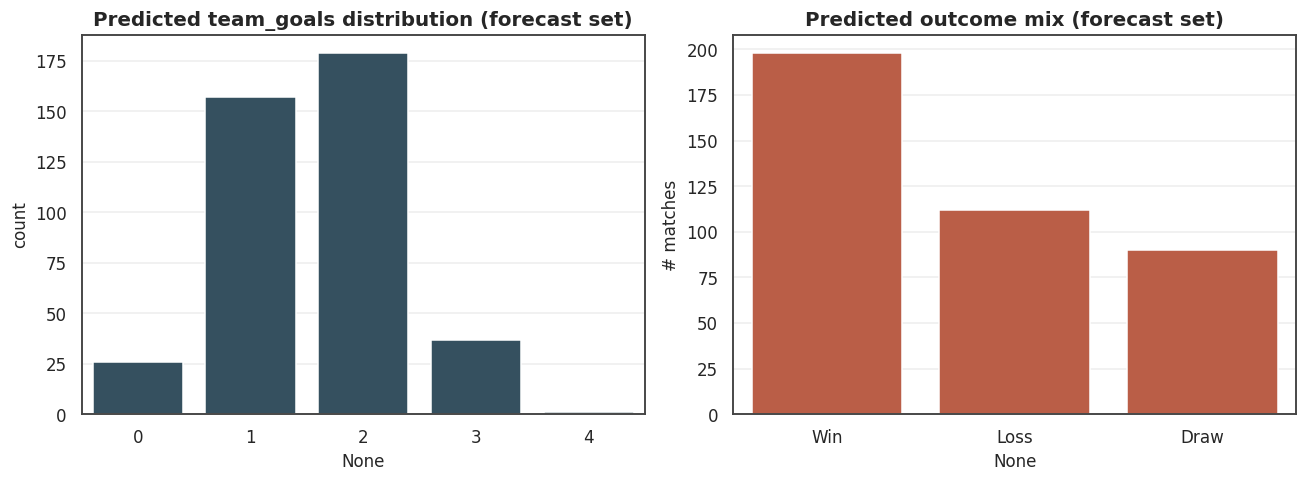

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x=pd.Series(final_home).clip(upper=5), color=PALETTE[0], ax=axes[0])
axes[0].set_title("Predicted team_goals distribution (forecast set)")

outcome_counts = pd.Series(np.where(np.array(final_home) > np.array(final_away), 'Win',
                            np.where(np.array(final_home) < np.array(final_away), 'Loss', 'Draw'))).value_counts()
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, color=PALETTE[5], ax=axes[1])
axes[1].set_title("Predicted outcome mix (forecast set)")
axes[1].set_ylabel("# matches")

plt.tight_layout()
plt.show()


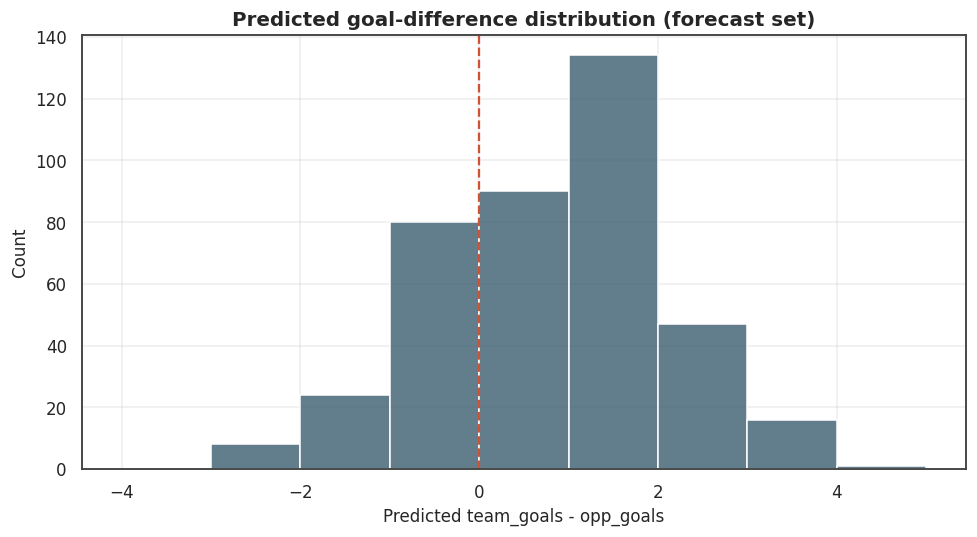

Draw rate in forecast: 22.5%
Draw rate in training data: 22.1%


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
goal_diff = np.array(final_home) - np.array(final_away)
sns.histplot(goal_diff, bins=range(int(goal_diff.min()) - 1, int(goal_diff.max()) + 2),
             color=PALETTE[0], ax=ax)
ax.axvline(0, color=PALETTE[5], ls='--')
ax.set_title("Predicted goal-difference distribution (forecast set)")
ax.set_xlabel("Predicted team_goals - opp_goals")
plt.tight_layout()
plt.show()

print(f"Draw rate in forecast: {(goal_diff == 0).mean()*100:.1f}%")
print(f"Draw rate in training data: {(train_hist['team_goals'] == train_hist['opp_goals']).mean()*100:.1f}%")


The forecast's draw rate landing in the same neighborhood as the historical
training draw rate is the cheapest possible regression test for this whole
sequential loop — if the `aw_mae_rounder` threshold were mis-set, or the
state update had a bug feeding back into itself, this number would drift far
away from the historical baseline well before anyone noticed from the raw
predictions alone.

**Pipeline complete.** `../outputs/submission_final.csv` is ready to submit;
swap `generate_dummy_data.py`'s output for the real `train.csv` / `test.csv`
to run this end-to-end on production data.